Predicting Employee Attrition

In [135]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\USER\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")  # Replace with your actual file name

# Display first few rows
print(df.head())

# Check data types
print(df.dtypes)


   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [137]:
# Drop unnecessary columns
df.drop(columns=["EmployeeCount", "EmployeeNumber", "StandardHours", "Over18"], inplace=True)

# Check for missing values
print(df.isnull().sum())

# Convert categorical variables to numerical
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Show transformed data
print(df.head())


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64
   Age  Attrition  BusinessTravel  DailyRate  Department 

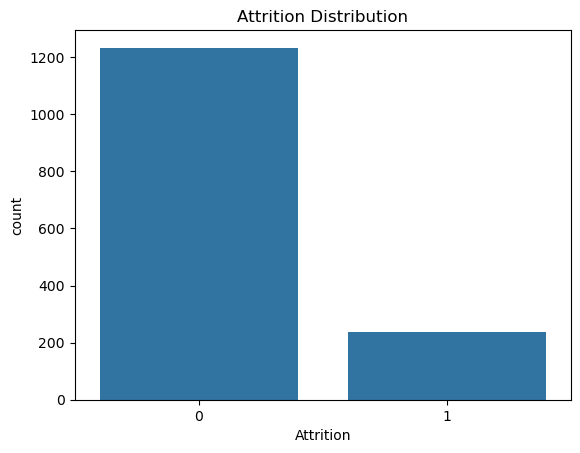

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64


In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot of Attrition
sns.countplot(x=df["Attrition"])
plt.title("Attrition Distribution")
plt.show()

# Print class distribution
print(df["Attrition"].value_counts(normalize=True))


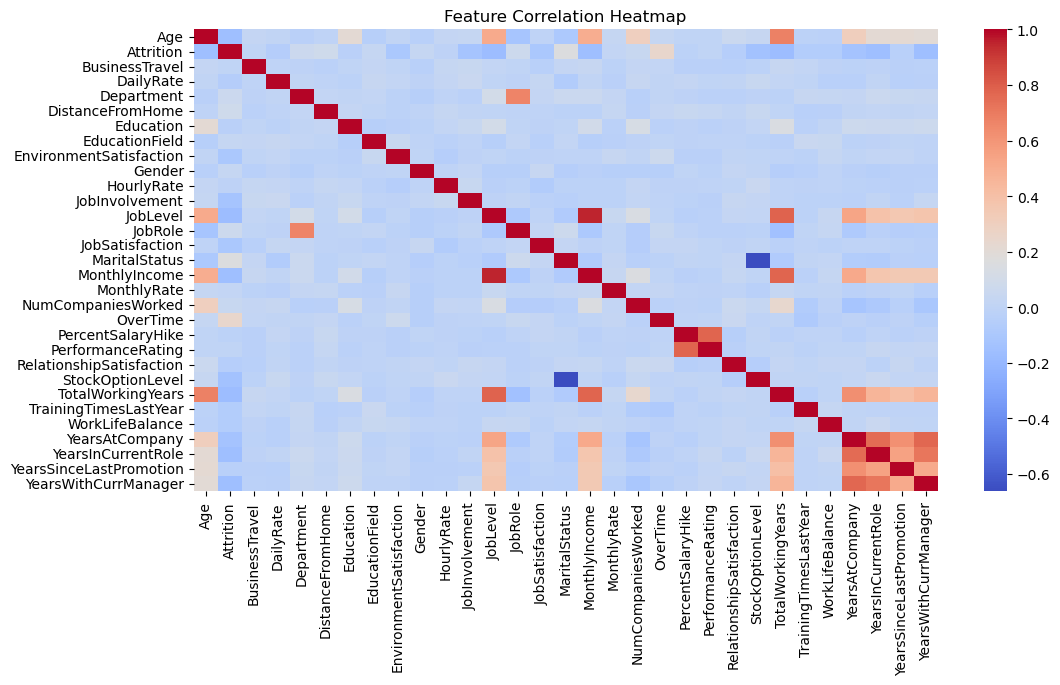

In [141]:
import numpy as np

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


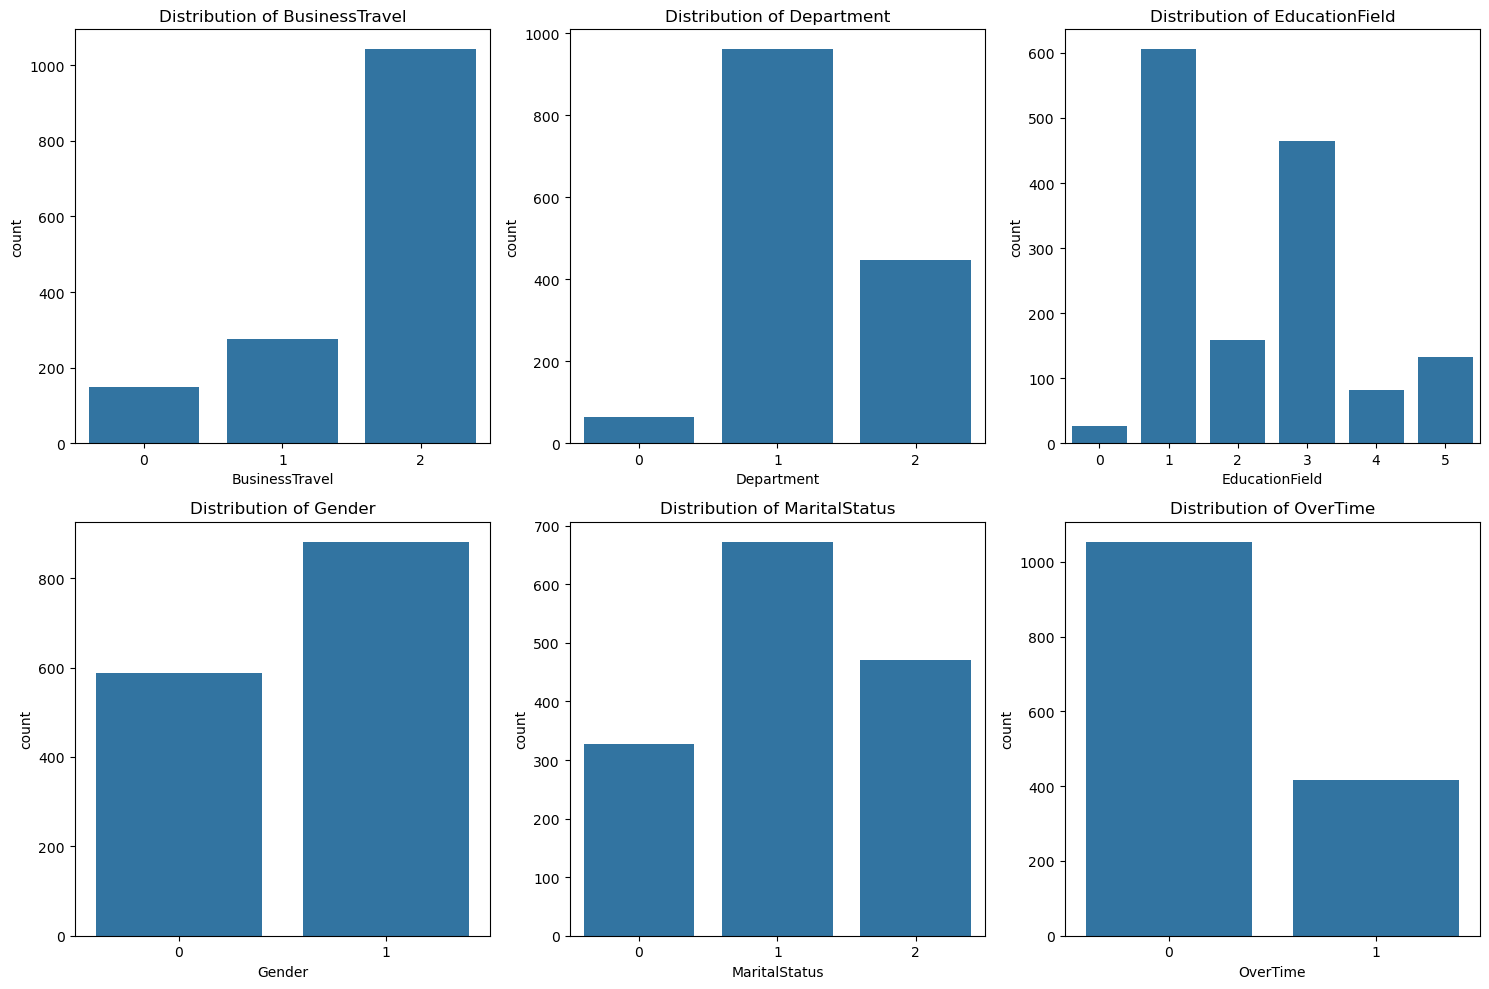

In [143]:
# Select categorical columns
categorical_cols = ["BusinessTravel", "Department", "EducationField", "Gender", "MaritalStatus", "OverTime"]

# Plot categorical distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


In [149]:
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop(columns=["Attrition"])  # Features
y = df["Attrition"]  # Target variable

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Increase minority class to 50%
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print(y_resampled.value_counts(normalize=True))


Attrition
0    0.666847
1    0.333153
Name: proportion, dtype: float64


In [151]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # Reduce class 0 to 50%
X_resampled, y_resampled = rus.fit_resample(X, y)

print(y_resampled.value_counts(normalize=True))


Attrition
0    0.666667
1    0.333333
Name: proportion, dtype: float64


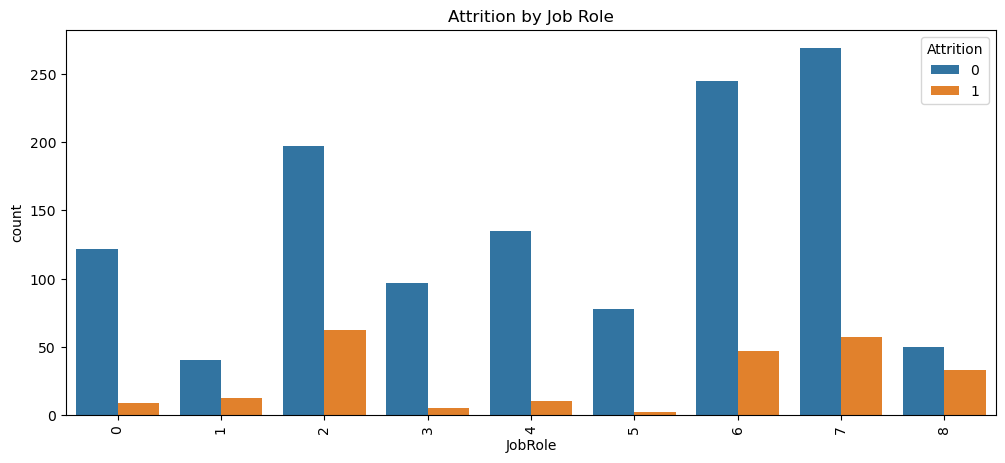

In [155]:
import seaborn as sns

plt.figure(figsize=(12,5))
sns.countplot(x=df["JobRole"], hue=df["Attrition"])
plt.xticks(rotation=90)
plt.title("Attrition by Job Role")
plt.show()


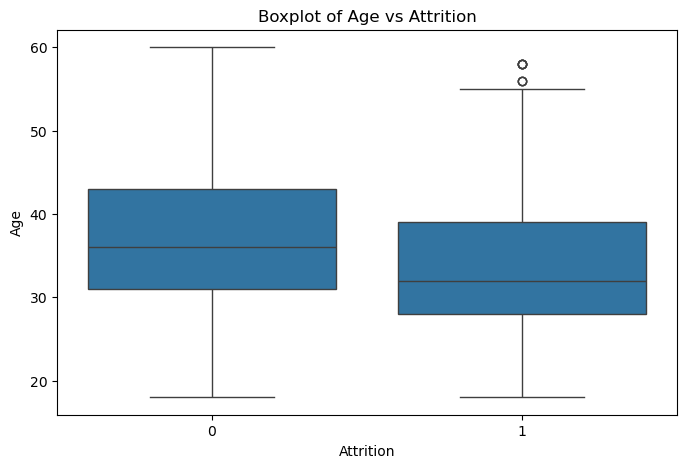

In [157]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Attrition"], y=df["Age"])
plt.title("Boxplot of Age vs Attrition")
plt.show()


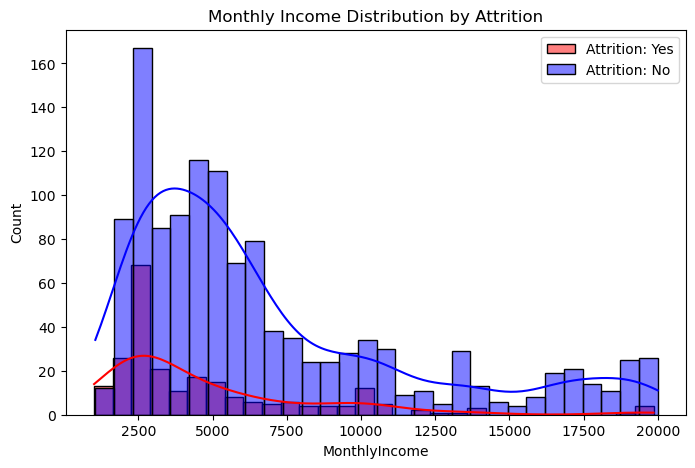

In [159]:
plt.figure(figsize=(8,5))
sns.histplot(df[df["Attrition"] == 1]["MonthlyIncome"], kde=True, bins=30, color="red", label="Attrition: Yes")
sns.histplot(df[df["Attrition"] == 0]["MonthlyIncome"], kde=True, bins=30, color="blue", label="Attrition: No")
plt.legend()
plt.title("Monthly Income Distribution by Attrition")
plt.show()


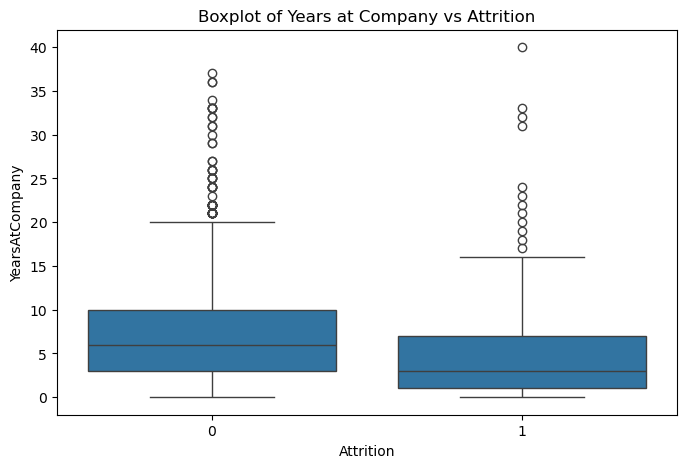

In [161]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Attrition"], y=df["YearsAtCompany"])
plt.title("Boxplot of Years at Company vs Attrition")
plt.show()


In [163]:
df = pd.get_dummies(df, drop_first=True)


In [165]:
from sklearn.model_selection import train_test_split

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [241]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [243]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [245]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7993197278911565
Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88       247
           1       0.34      0.28      0.31        47

    accuracy                           0.80       294
   macro avg       0.60      0.59      0.59       294
weighted avg       0.78      0.80      0.79       294



In [247]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)


In [249]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_under, y_train_under)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Report:\n", classification_report(y_test, y_pred))


Random Forest Accuracy: 0.7448979591836735
Random Forest Report:
               precision    recall  f1-score   support

           0       0.92      0.76      0.83       247
           1       0.34      0.66      0.45        47

    accuracy                           0.74       294
   macro avg       0.63      0.71      0.64       294
weighted avg       0.83      0.74      0.77       294



In [251]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None],
}

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, 
                                   n_iter=10, cv=5, random_state=42, n_jobs=-1)

# Fit the random search model
random_search.fit(X_train_resampled, y_train_resampled)

# Best parameters
print(f"Best Parameters: {random_search.best_params_}")

# Use the best estimator
best_rf_model = random_search.best_estimator_

# Evaluate the model
y_pred = best_rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}
Accuracy: 0.8095238095238095
Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       247
           1       0.39      0.34      0.36        47

    accuracy                           0.81       294
   macro avg       0.63      0.62      0.63       294
weighted avg       0.80      0.81      0.80       294



In [269]:
!pip install shap


In [277]:
print(rf_model)



RandomForestClassifier(random_state=42)


In [279]:
# Ensure the model is trained on resampled data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)  # Fit the model to the resampled data


RandomForestClassifier(random_state=42)

In [285]:
print(X_train_resampled.shape)
print(len(shap_values))


(1972, 30)
1972


In [287]:
# Check the shape of SHAP values for both classes
print(shap_values[0].shape)
print(shap_values[1].shape)


(30, 2)
(30, 2)


In [295]:
print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of shap_values:", len(shap_values))  # Length of shap_values should correspond to the number of classes


Shape of X_train_resampled: (1972, 30)
Shape of shap_values: 1972


In [297]:
print("Length of shap_values:", len(shap_values))
print("First few rows of shap_values:", shap_values[0][:5])  # Print first 5 values of shap_values for class 0


Length of shap_values: 1972
First few rows of shap_values: [[ 0.04357476 -0.04357476]
 [ 0.02486317 -0.02486317]
 [ 0.01635469 -0.01635469]
 [-0.00051136  0.00051136]
 [ 0.02720637 -0.02720637]]


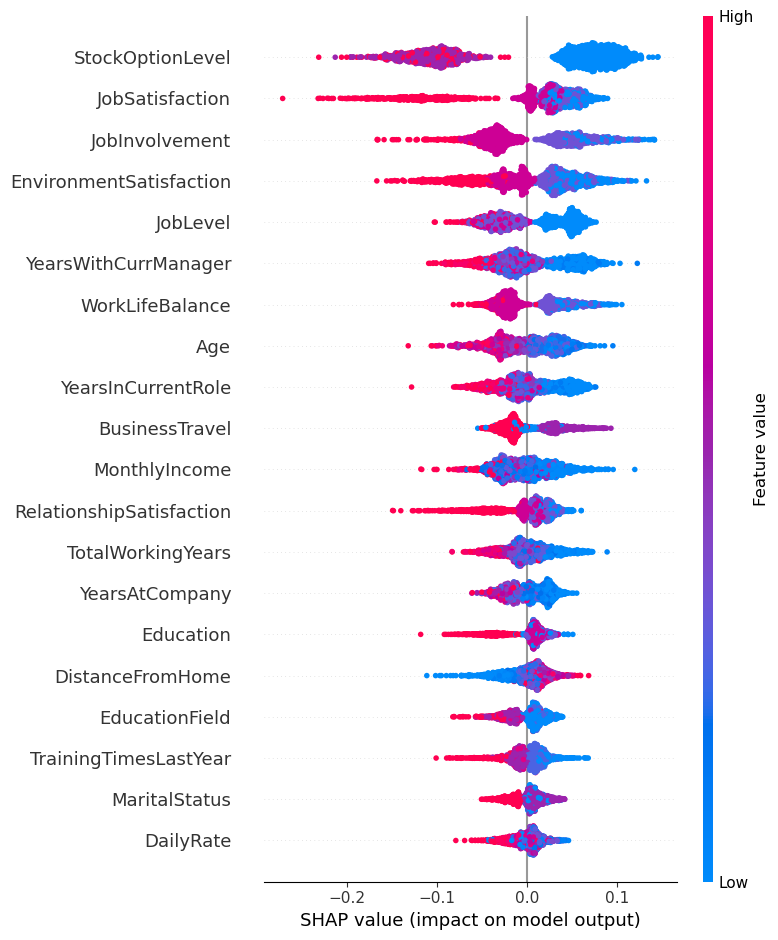

In [315]:
shap.summary_plot(shap_values[:, :, 1], X_train_resampled)


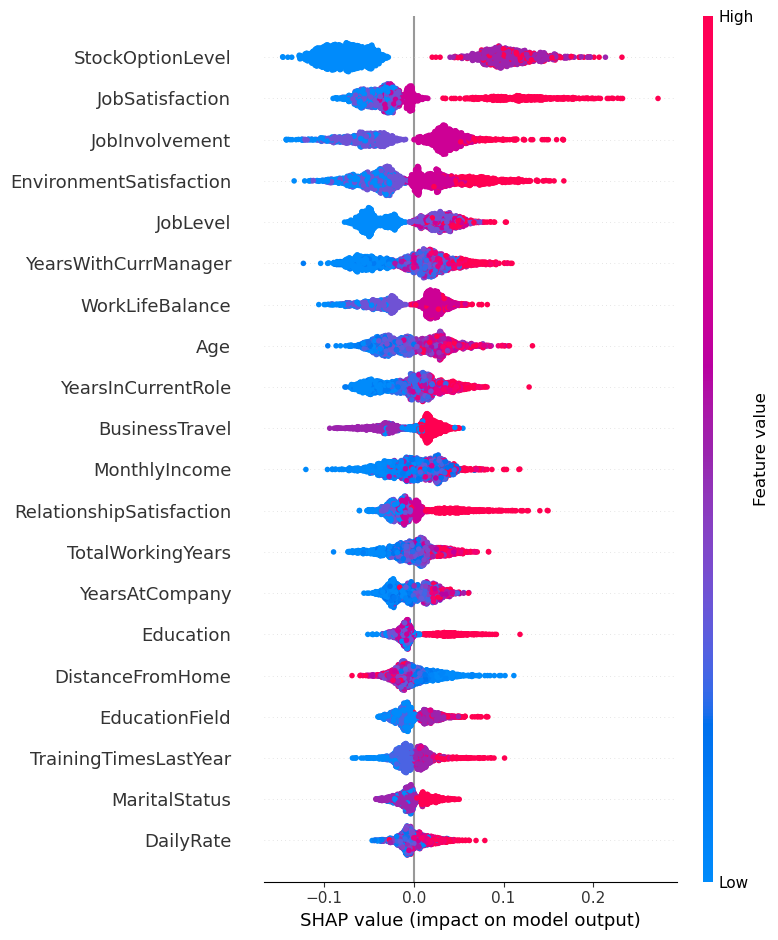

In [313]:
shap.summary_plot(shap_values[:, :, 0], X_train_resampled)


<Figure size 640x480 with 0 Axes>

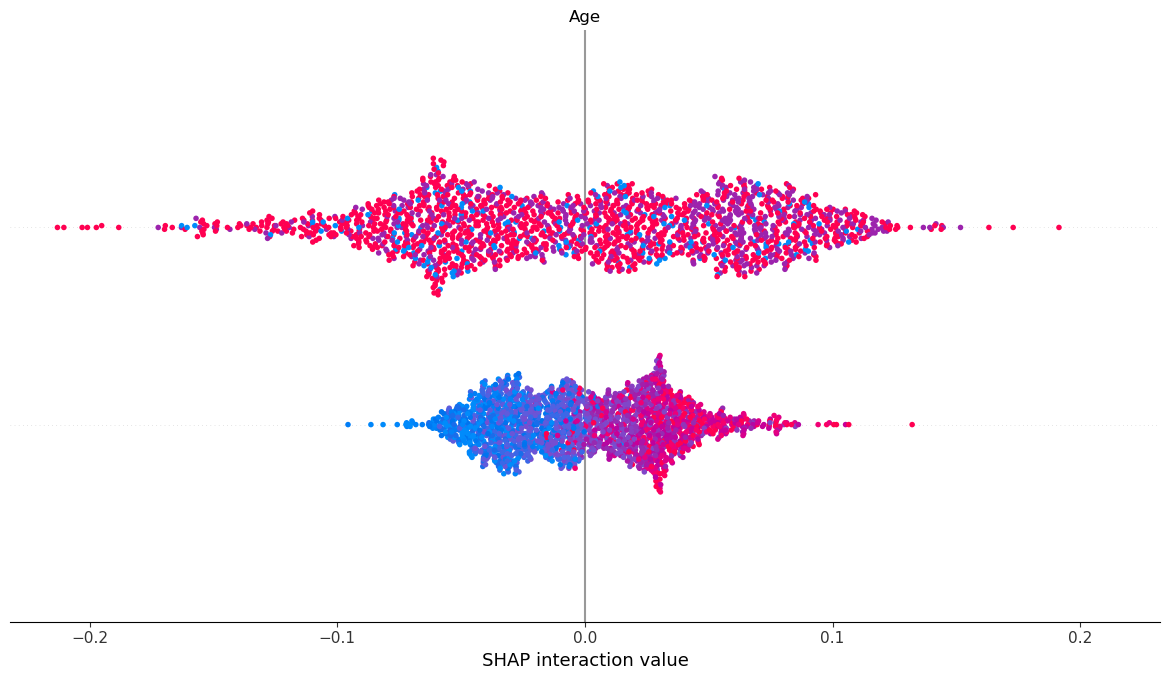

In [303]:
# Alternatively, you can just pass the entire shap_values array for the second class
shap.summary_plot(shap_values, X_train_resampled)


              precision    recall  f1-score   support

           0       0.87      0.90      0.88       247
           1       0.34      0.28      0.31        47

    accuracy                           0.80       294
   macro avg       0.60      0.59      0.59       294
weighted avg       0.78      0.80      0.79       294

Confusion Matrix:
 [[222  25]
 [ 34  13]]


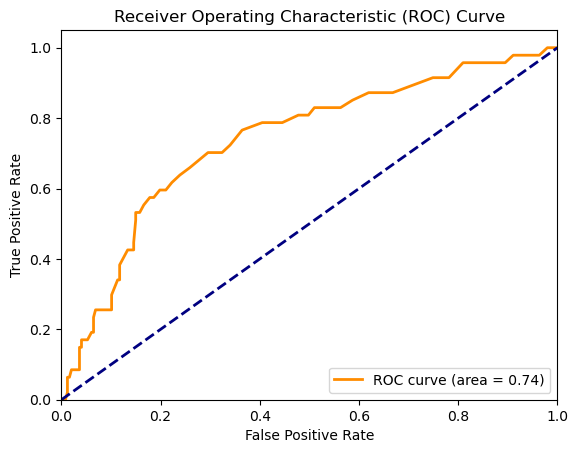

In [317]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Evaluate Random Forest model
y_pred = rf_model.predict(X_test)  # Assuming rf_model is the trained model

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


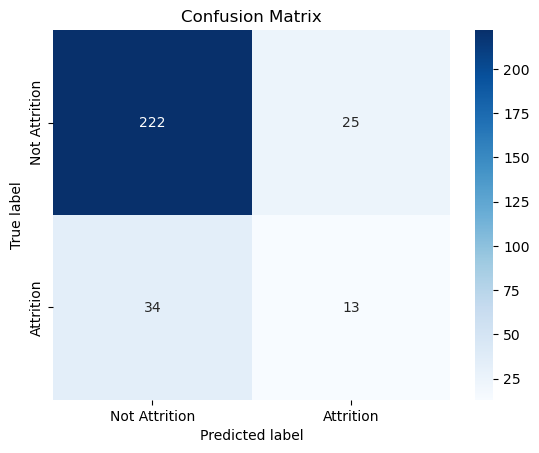

In [320]:
import seaborn as sns

# Confusion matrix visualization
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Attrition', 'Attrition'], yticklabels=['Not Attrition', 'Attrition'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()
